In [14]:
#import libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:
#import dataset
df=pd.read_csv('../data/processed/train_prepared.csv')
df

,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
1,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
2,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
3,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,0.355089,0.13,0.644231,C8,8794,2,A,M3,Petrol,91Nm@4250rpm,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0
58588,1.199642,0.02,0.519231,C14,7788,1,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
58589,1.162273,0.05,0.451923,C5,34738,1,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
58590,1.236307,0.14,0.557692,C8,8794,1,B2,M6,Petrol,113Nm@4400rpm,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0


# Understand target variable distribution

In [16]:
#target distribution
df['is_claim'].value_counts()

is_claim
0    54844
1     3748
Name: count, dtype: int64

In [17]:
#target  percentages
df['is_claim'].value_counts(normalize=True)*100

is_claim
0    93.603222
1     6.396778
Name: proportion, dtype: float64

# Observation 


The target variable `is_claim` is strongly imbalanced:

- 93.60% of policies have no claim (`0`).
- 6.40% of policies have a claim (`1`).

This indicates a significant class imbalance, which should be considered during model training and evaluation.

# Understanding Numerical Features


In [18]:
# Numerical features
numerical_features = [
    "policy_tenure",
    "age_of_car",
    "age_of_policyholder",
    "population_density",
    "airbags",
    "displacement",
    "cylinder",
    "turning_radius",
    "length",
    "width",
    "height",
    "gross_weight"
]

# Categorical features
categorical_features = [
    "area_cluster",
    "make",
    "segment",
    "model",
    "fuel_type",
    "engine_type",
    "rear_brakes_type",
    "transmission_type",
    "steering_type",
    "gear_box",
    "ncap_rating"
]


In [19]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
policy_tenure,58592.0,0.611246,0.414156,0.002735,0.210250,0.573792,1.039104,1.396641
age_of_car,58592.0,0.069424,0.056721,0.000000,0.020000,0.060000,0.110000,1.000000
age_of_policyholder,58592.0,0.469420,0.122886,0.288462,0.365385,0.451923,0.548077,1.000000
population_density,58592.0,18826.858667,17660.174792,290.000000,6112.000000,8794.000000,27003.000000,73430.000000
airbags,58592.0,3.137066,1.832641,1.000000,2.000000,2.000000,6.000000,6.000000
displacement,58592.0,1162.355851,266.304786,796.000000,796.000000,1197.000000,1493.000000,1498.000000
cylinder,58592.0,3.626963,0.483616,3.000000,3.000000,4.000000,4.000000,4.000000
turning_radius,58592.0,4.852893,0.228061,4.500000,4.600000,4.800000,5.000000,5.200000
length,58592.0,3850.476891,311.457119,3445.000000,3445.000000,3845.000000,3995.000000,4300.000000
width,58592.0,1672.233667,112.089135,1475.000000,1515.000000,1735.000000,1755.000000,1811.000000


In [20]:
#calculate skewness of all numerical features
df[numerical_features].skew().sort_values(ascending=False)

population_density     1.674178
age_of_car             1.094081
height                 1.035498
airbags                0.905946
age_of_policyholder    0.640049
gross_weight           0.546949
turning_radius         0.420983
length                 0.145801
policy_tenure          0.053588
displacement          -0.105317
width                 -0.488392
cylinder              -0.525074
dtype: float64

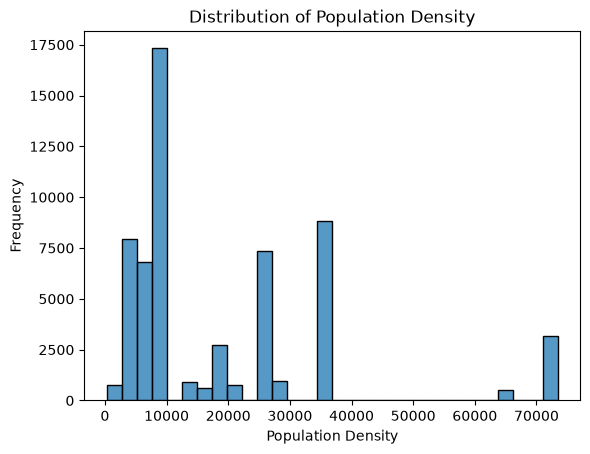

In [21]:
sns.histplot(data=df, x="population_density", bins=30)

plt.xlabel("Population Density")
plt.ylabel("Frequency")
plt.title("Distribution of Population Density")

plt.show()

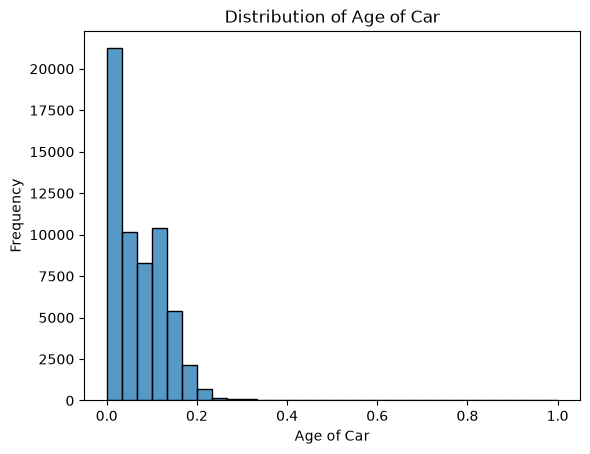

In [24]:
#age_of_car
sns.histplot(data=df, x="age_of_car", bins=30)

plt.xlabel("Age of Car")
plt.ylabel("Frequency")
plt.title("Distribution of Age of Car")

plt.show()

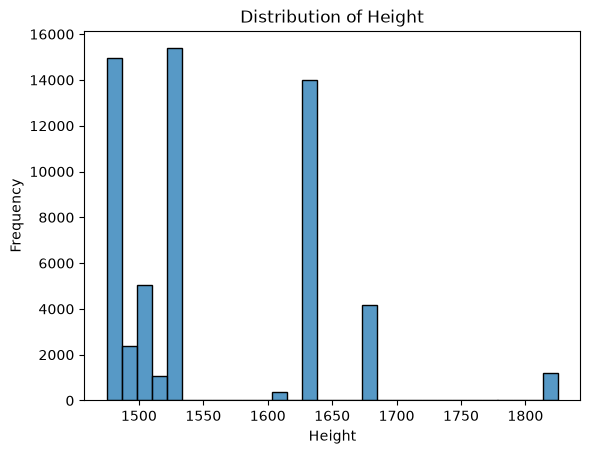

In [26]:
#height
sns.histplot(data=df, x="height", bins=30)

plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Distribution of Height")

plt.show()

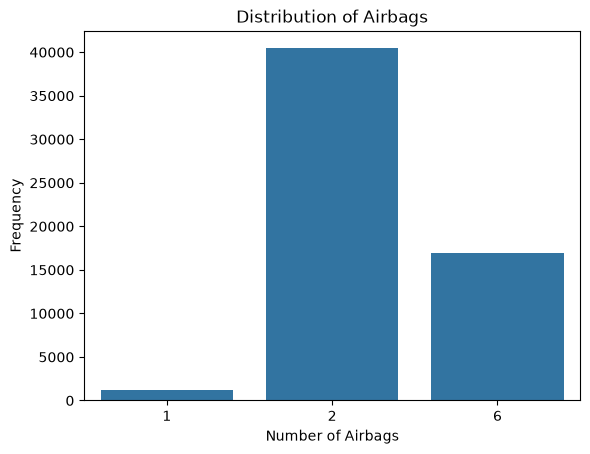

In [27]:
#airbags
sns.countplot(data=df, x="airbags")

plt.xlabel("Number of Airbags")
plt.ylabel("Frequency")
plt.title("Distribution of Airbags")

plt.show()

# Understand categorical features

In [ ]:
#How many different categories does each feature have, and how frequently do they occur?
df[categorical_features].nunique().sort_values()

rear_brakes_type      2
transmission_type     2
gear_box              2
fuel_type             3
steering_type         3
ncap_rating           5
make                  5
segment               6
model                11
engine_type          11
area_cluster         22
dtype: int64

In [29]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- area_cluster ---
area_cluster
C8     13654
C2      7342
C5      6979
C3      6101
C14     3660
C13     3423
C10     3155
C9      2734
C7      2167
C12     1589
C1      1468
C11     1212
C19      952
C6       890
C15      771
C4       665
C17      492
C16      401
C21      379
C18      242
C22      207
C20      109
Name: count, dtype: int64

--- make ---
make
1    38126
3    14018
2     2373
5     2114
4     1961
Name: count, dtype: int64

--- segment ---
segment
B2         18314
A          17321
C2         14018
B1          4173
C1          3557
Utility     1209
Name: count, dtype: int64

--- model ---
model
M1     14948
M4     14018
M6     13776
M8      4173
M7      2940
M3      2373
M9      2114
M5      1598
M10     1209
M2      1080
M11      363
Name: count, dtype: int64

--- fuel_type ---
fuel_type
Petrol    20532
CNG       20330
Diesel    17730
Name: count, dtype: int64

--- engine_type ---
engine_type
F8D Petrol Engine            14948
1.5 L U2 CRDi                14018
K Se

# Analyze feature vs target


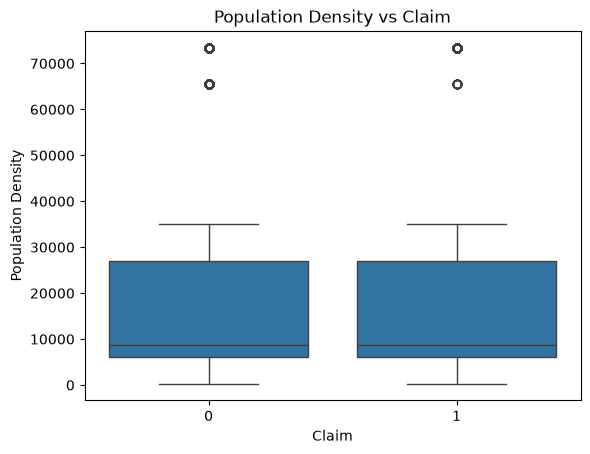

In [30]:
sns.boxplot(data=df, x="is_claim", y="population_density")

plt.xlabel("Claim")
plt.ylabel("Population Density")
plt.title("Population Density vs Claim")

plt.show()

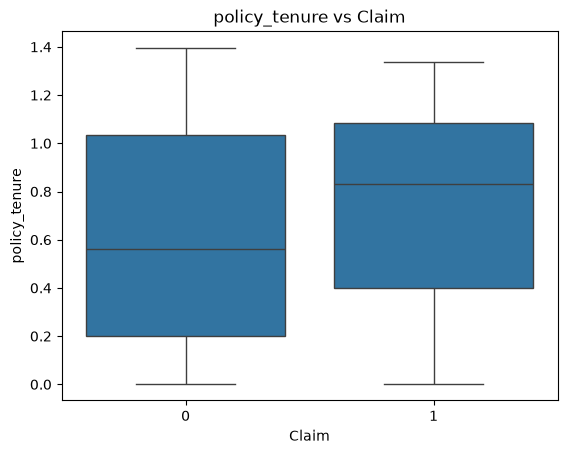

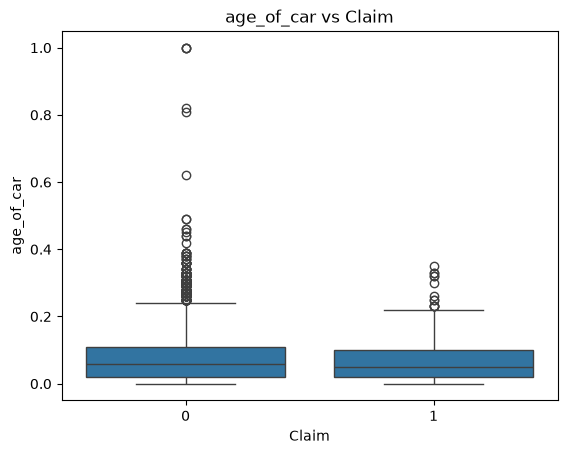

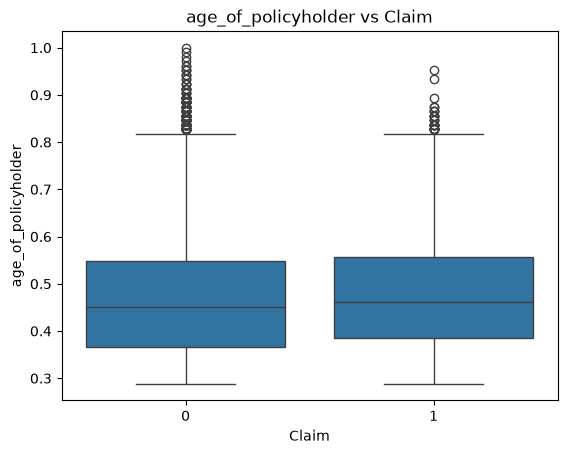

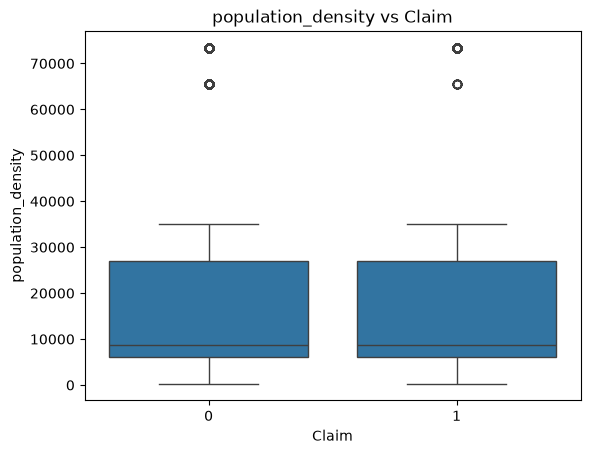

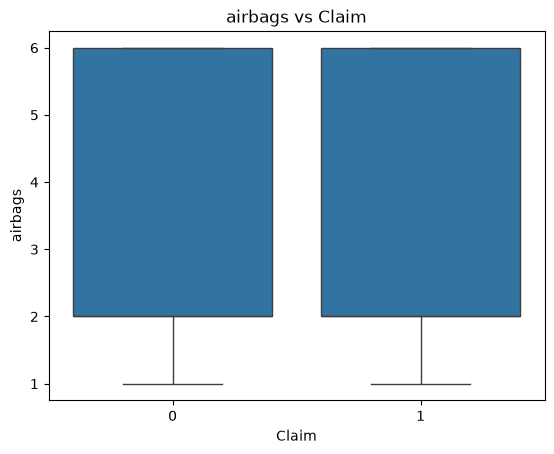

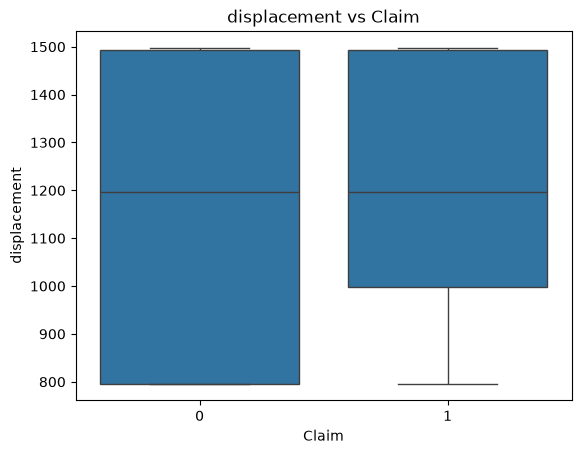

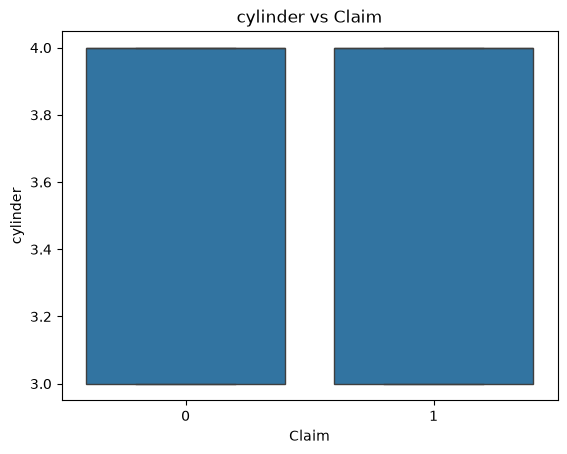

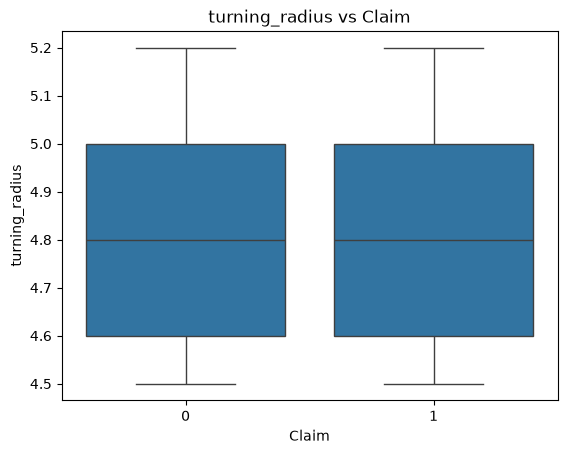

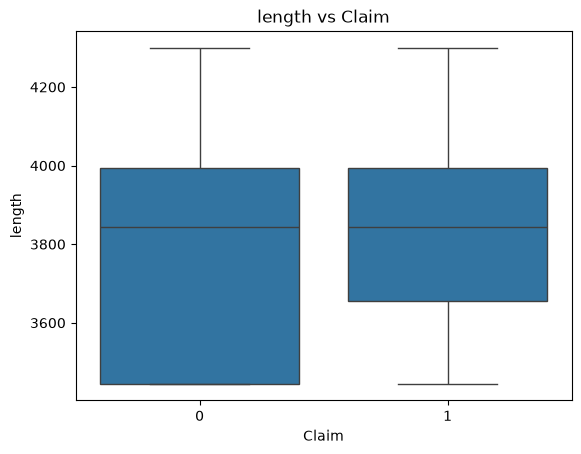

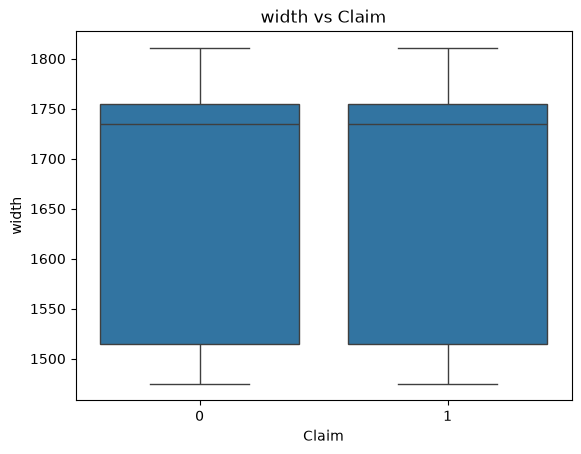

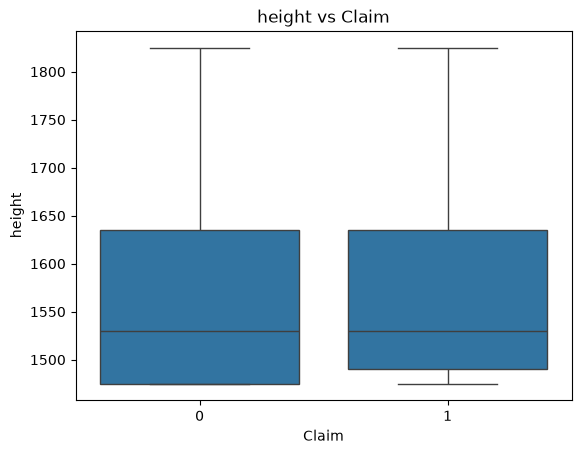

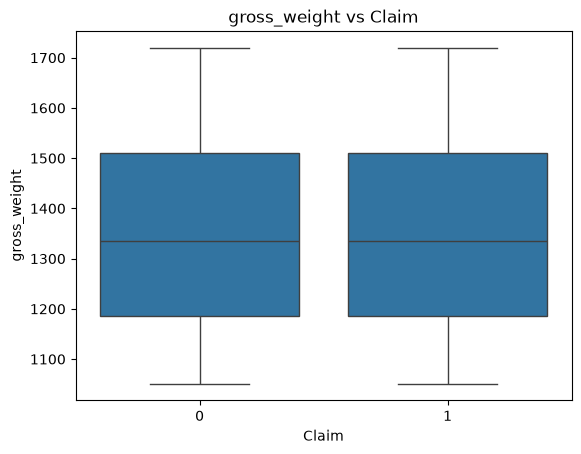

In [32]:
features_to_plot = [
    "policy_tenure",
    "age_of_car",
    "age_of_policyholder",
    "population_density",
    "airbags",
    "displacement",
    "cylinder",
    "turning_radius",
    "length",
    "width",
    "height",
    "gross_weight"
]

for feature in features_to_plot:
    sns.boxplot(data=df, x="is_claim", y=feature)
    plt.xlabel("Claim")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Claim")
    plt.show()

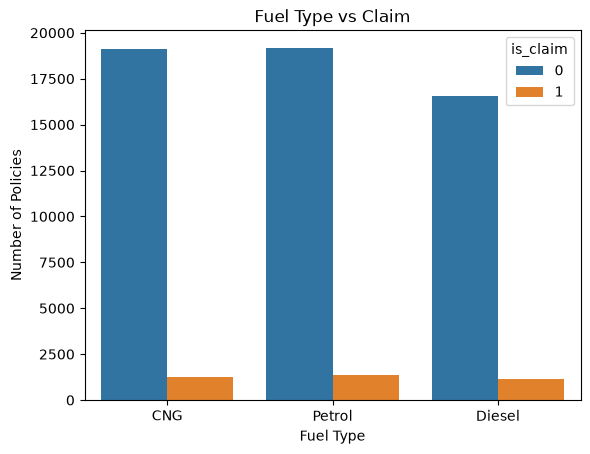

In [33]:
#categorical vs target 
sns.countplot(data=df, x="fuel_type", hue="is_claim")

plt.xlabel("Fuel Type")
plt.ylabel("Number of Policies")
plt.title("Fuel Type vs Claim")

plt.show()

In [34]:
df.groupby("fuel_type")["is_claim"].mean().sort_values(ascending=False)

fuel_type
Petrol    0.066384
Diesel    0.064862
CNG       0.060748
Name: is_claim, dtype: float64

In [35]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)["is_claim"]
        .mean()
        .sort_values(ascending=False)
    )


--- area_cluster ---
area_cluster
C18    0.107438
C22    0.082126
C14    0.076776
C4     0.076692
C21    0.076517
C19    0.074580
C3     0.070972
C2     0.070825
C8     0.069870
C6     0.061798
C11    0.059406
C5     0.057745
C16    0.057357
C13    0.056968
C12    0.054751
C1     0.051771
C7     0.050300
C9     0.049744
C15    0.049287
C10    0.046910
C20    0.045872
C17    0.038618
Name: is_claim, dtype: float64

--- make ---
make
4    0.066803
1    0.064392
3    0.064275
5    0.062914
2    0.053940
Name: is_claim, dtype: float64

--- segment ---
segment
B2         0.068581
C2         0.064275
C1         0.064099
A          0.060389
Utility    0.060380
B1         0.058471
Name: is_claim, dtype: float64

--- model ---
model
M2     0.074074
M5     0.072591
M7     0.068367
M6     0.068162
M4     0.064275
M9     0.062914
M1     0.061413
M10    0.060380
M8     0.058471
M3     0.053940
M11    0.041322
Name: is_claim, dtype: float64

--- fuel_type ---
fuel_type
Petrol    0.066384
Diesel    

# Numerical Relationships

In [36]:
df[numerical_features].corr()

,policy_tenure,age_of_car,age_of_policyholder,population_density,airbags,displacement,cylinder,turning_radius,length,width,height,gross_weight
policy_tenure,1.000000,0.166312,0.143676,-0.100307,0.103981,0.194361,0.191185,0.166426,0.190869,0.213228,0.119055,0.141027
age_of_car,0.166312,1.000000,-0.035427,-0.062255,0.209073,0.393208,0.379522,0.332716,0.383177,0.414104,0.259156,0.302127
age_of_policyholder,0.143676,-0.035427,1.000000,0.009669,-0.008041,-0.023764,0.004183,-0.016764,-0.020138,-0.006135,-0.053930,-0.007758
population_density,-0.100307,-0.062255,0.009669,1.000000,-0.060359,-0.090983,-0.091591,-0.077501,-0.091968,-0.098156,-0.065583,-0.077816
airbags,0.103981,0.209073,-0.008041,-0.060359,1.000000,0.661190,0.478594,0.810820,0.809094,0.639562,0.423816,0.828988
displacement,0.194361,0.393208,-0.023764,-0.090983,0.661190,1.000000,0.866231,0.875407,0.961655,0.899302,0.554591,0.776210
cylinder,0.191185,0.379522,0.004183,-0.091591,0.478594,0.866231,1.000000,0.615806,0.805476,0.862430,0.352118,0.602978
turning_radius,0.166426,0.332716,-0.016764,-0.077501,0.810820,0.875407,0.615806,1.000000,0.944899,0.825603,0.460436,0.823097
length,0.190869,0.383177,-0.020138,-0.091968,0.809094,0.961655,0.805476,0.944899,1.000000,0.915918,0.553579,0.861723
width,0.213228,0.414104,-0.006135,-0.098156,0.639562,0.899302,0.862430,0.825603,0.915918,1.000000,0.389317,0.734284


### Numerical Feature Relationships

The correlation analysis shows strong relationships among several vehicle-related numerical features.

For example, `displacement` is strongly correlated with `length` (0.96), `turning_radius` (0.88), and `cylinder` (0.87). `length` is also strongly correlated with `turning_radius` (0.94) and `width` (0.92).

These relationships suggest that some vehicle characteristics contain overlapping information.

No features are removed at this stage. The correlations will be considered during later preprocessing and model development.